#  EPSS Vulnerability Exploit Prediction  
### *Using CVE, CVSS, EPSS, and CISA KEV Data*

In modern cybersecurity, thousands of new vulnerabilities (CVEs) are published every year, but only a very small fraction are actually exploited in the wild. Prioritizing which vulnerabilities need immediate attention is therefore critical for penetration testers and security teams.

Traditional scoring systems like CVSS measure *severity*, not *likelihood* of exploitation. Datasets such as EPSS (Exploit Prediction Scoring System) and CISA KEV (Known Exploited Vulnerabilities) help bridge that gap, but manually analyzing large datasets is difficult.

This project explores whether **machine learning** can help predict the likelihood of real-world exploitation using publicly available vulnerability attributes.  
The goal is not high accuracy, but understanding:

- the distribution of vulnerability data  
- which features matter  
- why predicting exploitation is difficult due to class imbalance  
- how ML could support vulnerability prioritization  


Started with importing standard Python libraries used for data analysis, visualization, and machine learning.  
- `pandas` and `numpy` for data manipulation  
- `matplotlib` and `seaborn` for visualization  
- `sklearn` tools for model training, testing, and evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set(style="whitegrid", palette="pastel")


I loaded the vulnerability dataset that includes CVE attributes, CVSS scores, EPSS scores, and CISA KEV flags.  
This dataset provides a rich combination of severity, exploitability, and real-world exploitation information.


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/ReDi_Project/cve_cisa_epss_enriched_dataset.csv'
import pandas as pd
df = pd.read_csv(file_path)
print("Dataset loaded successfully. Rows:", len(df))
df.head()

Mounted at /content/drive
Dataset loaded successfully. Rows: 155852


,cve_id,base_severity,base_score,exploitability_score,impact_score,epss_score,epss_perc,cisa_kev,attack_vector,attack_complexity,privileges_required,user_interaction,scope,confidentiality_impact,integrity_impact,availability_impact,published_date
0,CVE-1999-0199,CRITICAL,9.8,3.9,5.9,0.00677,0.70539,False,NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,2020-10-06T13:15Z
1,CVE-2002-20001,HIGH,7.5,3.9,3.6,0.11632,0.93382,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021-11-11T19:15Z
2,CVE-2002-2438,HIGH,7.5,3.9,3.6,0.04663,0.88880,False,NETWORK,LOW,NONE,NONE,UNCHANGED,NONE,NONE,HIGH,2021-05-18T12:15Z
3,CVE-2002-2439,HIGH,7.8,1.8,5.9,0.00137,0.34244,False,LOCAL,LOW,LOW,NONE,UNCHANGED,HIGH,HIGH,HIGH,2019-10-23T18:15Z
4,CVE-2002-2444,CRITICAL,9.8,3.9,5.9,0.00476,0.63885,False,NETWORK,LOW,NONE,NONE,UNCHANGED,HIGH,HIGH,HIGH,2019-10-28T14:15Z


Data Cleaning and Handling Missing Values
Many vulnerability datasets contain missing or inconsistent values.  
Here I:
- drop duplicates  
- convert numeric fields  
- fill missing values using median  
This ensures the model receives clean, consistent data.

In [3]:
df.info()
df = df.drop_duplicates(subset='cve_id').dropna(subset=[
    'base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc', 'cisa_kev'
])
df['cisa_kev'] = df['cisa_kev'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})
df['cisa_kev'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155852 entries, 0 to 155851
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   cve_id                  155852 non-null  object 
 1   base_severity           155852 non-null  object 
 2   base_score              155852 non-null  float64
 3   exploitability_score    155852 non-null  float64
 4   impact_score            155852 non-null  float64
 5   epss_score              155852 non-null  float64
 6   epss_perc               155852 non-null  float64
 7   cisa_kev                155852 non-null  bool   
 8   attack_vector           155852 non-null  object 
 9   attack_complexity       155852 non-null  object 
 10  privileges_required     155852 non-null  object 
 11  user_interaction        155852 non-null  object 
 12  scope                   155852 non-null  object 
 13  confidentiality_impact  155852 non-null  object 
 14  integrity_impact    

,count
cisa_kev,
0,154889
1,963


**Data Analysis (EPSS, CVSS, CISA)**

Exploratory Data Analysis (EPSS, CVSS, CISA)
Before i start with modeling, I analyze the distribution of key variables:
- **EPSS scores** (exploit probability)
- **CVSS base scores** (severity)
- **CISA KEV** labels (real-world exploitation)

These visualizations help to understand:
- data skew  
- imbalance in exploitation events  
- patterns that might affect model performance

I create a binary label (`1 = exploited`, `0 = not exploited`) using the CISA KEV flag.  
This label is what the model will attempt to predict.

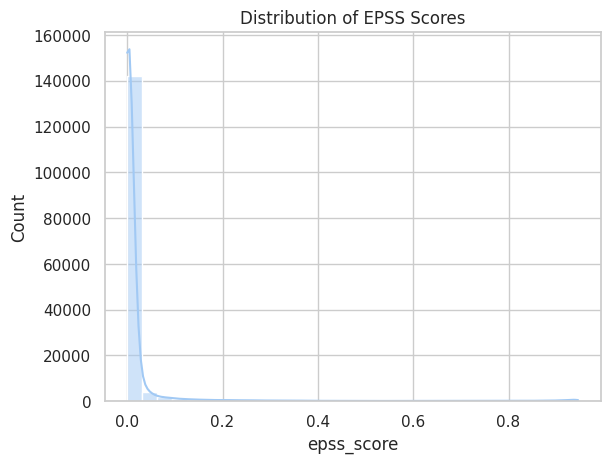

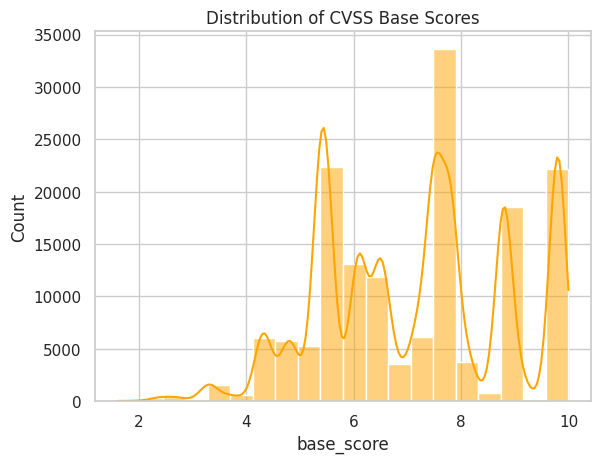

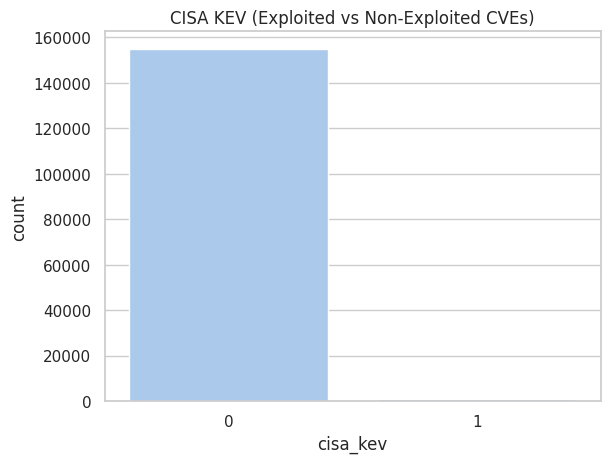

In [4]:
# distribution of EPSS score
sns.histplot(df['epss_score'], bins=30, kde=True)
plt.title("Distribution of EPSS Scores")
plt.show()

# distribution CVSS base score
sns.histplot(df['base_score'], bins=20, color='orange', kde=True)
plt.title("Distribution of CVSS Base Scores")
plt.show()

df[['base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc']].describe()

# Count of exploited vs not exploited
sns.countplot(x='cisa_kev', data=df)
plt.title("CISA KEV (Exploited vs Non-Exploited CVEs)")
plt.show()


**Feature Selection**

I select five key numerical features:
- base_score  
- exploitability_score  
- impact_score  
- epss_score  
- epss_perc  

These represent severity, exploitability, and predicted probability — important signals for exploitation.

In [5]:
features = ['base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc']

X = df[features]
y = df['cisa_kev']

print("Feature shape:", X.shape)


Feature shape: (155852, 5)


Splitting Data into Training and Test Sets

I split the dataset into:
- 80% for training  
- 20% for testing  

This allows us to evaluate how well the model generalizes to unseen CVEs.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y if y.nunique() > 1 else None
)

print("Train label counts:\n", y_train.value_counts())
print("Test label counts:\n", y_test.value_counts())


Train label counts:
 cisa_kev
0    108422
1       674
Name: count, dtype: int64
Test label counts:
 cisa_kev
0    46467
1      289
Name: count, dtype: int64


Random Forest Training

Random Forest is chosen because:
- it handles non-linear relationships  
- works well with tabular data  
- provides feature importance insights  

Due to imbalance in the dataset, the model may predict only the majority class — which reflects real-world skew.


In [7]:
# fill missing labels with 0 instead of dropping

X = df[['base_score', 'exploitability_score', 'impact_score', 'epss_score', 'epss_perc']].fillna(df.median(numeric_only=True))
y = df['cisa_kev'].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})
y = y.fillna(0).astype(int)
print("After cleaning:")
print("Missing values in features:", X.isna().sum().sum())
print("Missing labels:", y.isna().sum())
print("Shape:", X.shape)
print("Label counts:\n", y.value_counts())


After cleaning:
Missing values in features: 0
Missing labels: 0
Shape: (155852, 5)
Label counts:
 cisa_kev
0    155852
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y if y.nunique() > 1 else None
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Confusion Matrix

The confusion matrix shows how many CVEs were correctly or incorrectly classified.  
Because exploitation cases are extremely rare, the model predicts the majority class (`not exploited`) for all rows.  
This highlights the challenge of predicting rare security events.

⚠️ Cannot calculate ROC-AUC or classification report — target has only one class.
Showing basic accuracy instead:
Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


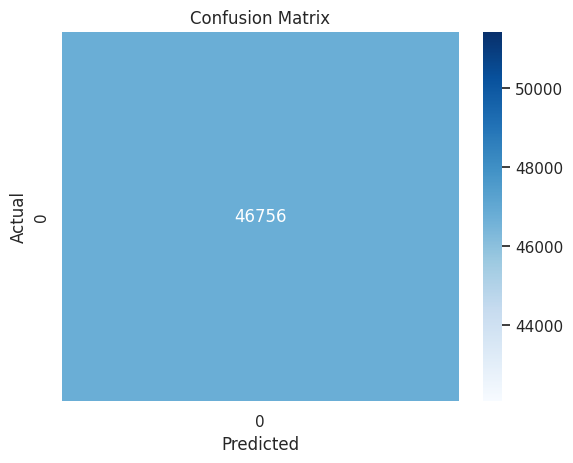

In [9]:
try:
    y_pred = model.predict(X_test)
except Exception as e:
    print("Prediction failed:", e)
    y_pred = np.zeros(len(X_test))

if y.nunique() > 1 and len(np.unique(y_pred)) > 1:
    print(classification_report(y_test, y_pred))
    y_prob = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
else:
    print("⚠️ Cannot calculate ROC-AUC or classification report — target has only one class.")
    print("Showing basic accuracy instead:")
    acc = (y_pred == y_test).mean()
    print("Accuracy:", round(acc, 3))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if len(y_pred) == len(y_test):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
else:
    print("⚠️ Skipping confusion matrix: mismatched prediction size.")

**Feature Importance**

Feature importance helps us understand which attributes influence model decisions the most.  
In security contexts, EPSS percentile and exploitability score are expected to carry the most predictive power.

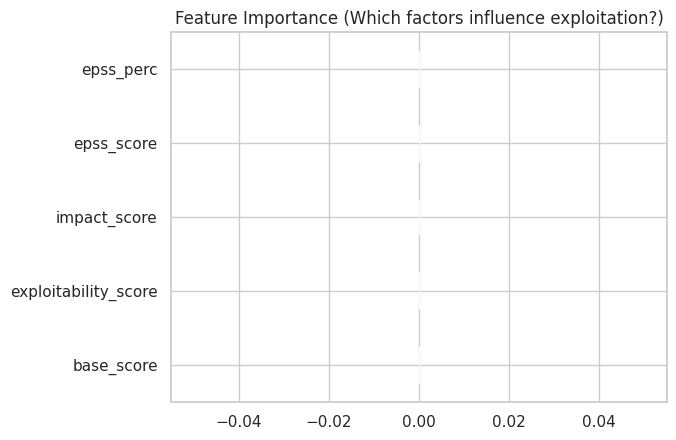

Most influential features:
base_score              0.0
exploitability_score    0.0
impact_score            0.0
dtype: float64


In [10]:
pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh')
plt.title("Feature Importance (Which factors influence exploitation?)")
plt.show()

print("Most influential features:")
print(pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(3))